In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


In [ ]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:, ['production','coolDD']]

x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()

model1.params

,0
const,1544742.70
production,31.98
coolDD,-23477.27


revenue = 1544742.7 + 31.98 * production -23477.27 * coolDD

In [ ]:
x_test = dt4testing.loc[:,['production','coolDD']]
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

model1_assessment['model1_abs_pct_error'] = abs(
    (
        model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
        )/model1_assessment['revenue']
    )

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,20938961.80,0.09
37,dt4testing,2014-02-28,26792280,714128,0,938,24384378.09,0.09
38,dt4testing,2014-03-31,19935840,805600,0,866,27309886.02,0.37
39,dt4testing,2014-04-30,13468000,375856,0,412,13565576.50,0.01
40,dt4testing,2014-05-31,7344128,279296,49,88,9326955.28,0.27
41,dt4testing,2014-06-30,11196216,517600,230,0,12699139.92,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,16593408.05,0.19
43,dt4testing,2014-08-31,12352176,663432,322,0,15203310.81,0.23
44,dt4testing,2014-09-30,12628944,701656,178,14,19806538.25,0.57
45,dt4testing,2014-10-31,9361000,411728,24,166,14149400.18,0.51


In [ ]:
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.21738596854659376)

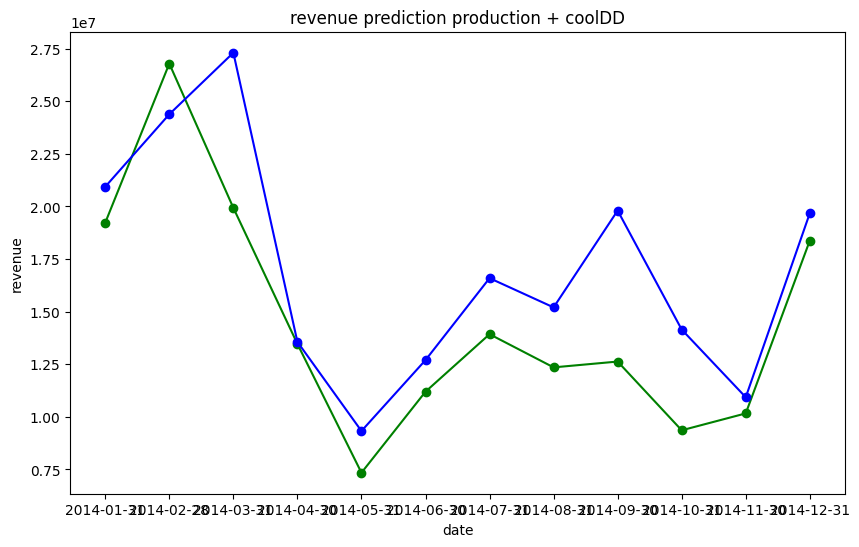

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue prediction production + coolDD')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model1_assessment['date'],model1_assessment['revenue'],marker='o',color='green')
plt.plot(model1_assessment['date'],model1_assessment['model1_predicted_revenue'],marker='o',color='blue')

#find the best model

#use univeriate regression models on production, cooldd, and heatdd
#then make multiple regression models

#submit your colab file showing your models being made and then a final visualization and text cell comparing your different models



#The best model is production + heatdd because it has a mape score of xyz while the others have a mape score of abc